# Hotel Booking Cancellation Prediction

## Notebook 01 — Data Understanding and Exploratory Data Analysis

**Module:** IT3051 – Fundamentals of Data Mining  
**Group:** Group 27 – Entropy Zero

### Machine Learning Task

Binary Classification

### Target Variable

`is_canceled`

- `0` — Not Cancelled
- `1` — Cancelled

### Notebook Objective

This notebook investigates the structure, quality, distributions, relationships,
and potential data leakage issues in the Hotel Booking Demand dataset before
data preprocessing and model development.


-------------------------------------

Import required libraries

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Connect repository

In [126]:
import os

REPO_NAME = "IT3051-Group27-Hotel-Cancellation-Prediction"
REPO_URL = f"https://github.com/sudulran/{REPO_NAME}.git"
REPO_PATH = f"/content/{REPO_NAME}"

if not os.path.exists(REPO_PATH):
    !git clone {REPO_URL}
else:
    print("Repository already cloned.")

%cd {REPO_PATH}

Repository already cloned.
/content/IT3051-Group27-Hotel-Cancellation-Prediction


Load raw dataset

In [127]:
DATA_PATH = "data/raw/hotel_bookings.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [128]:
print("Dataset shape:", df.shape)

Dataset shape: (119390, 32)


In [129]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Initial Dataset Inspection

This section examines the overall structure of the dataset, including its dimensions, column names, data types, and descriptive statistics.

Dataset dimensions and columns

In [130]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of rows: 119390
Number of columns: 32

Column names:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [132]:
dtype_summary = df.dtypes.value_counts()

print("Data type summary:")
display(dtype_summary)

Data type summary:


,count
int64,16
object,12
float64,4


In [133]:
numeric_dtype_columns = df.select_dtypes(include=np.number).columns.tolist()
object_dtype_columns = df.select_dtypes(include="object").columns.tolist()

print("Number of numeric dtype columns:", len(numeric_dtype_columns))
print("Number of object dtype columns:", len(object_dtype_columns))

print("\nNumeric dtype columns:")
print(numeric_dtype_columns)

print("\nObject dtype columns:")
print(object_dtype_columns)

Number of numeric dtype columns: 20
Number of object dtype columns: 12

Numeric dtype columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Object dtype columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


Numerical descriptive statistics

In [134]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


Categorical descriptive statistics

In [135]:
df.describe(include="object").T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


Unique-value counts

In [136]:
unique_counts = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique(dropna=False) for col in df.columns]
})

unique_counts

,Column,Unique Values
0,hotel,2
1,is_canceled,2
2,lead_time,479
3,arrival_date_year,3
4,arrival_date_month,12
5,arrival_date_week_number,53
6,arrival_date_day_of_month,31
7,stays_in_weekend_nights,17
8,stays_in_week_nights,35
9,adults,14


## 2. Target Variable Analysis

The target variable for this project is `is_canceled`.

- `0` represents a booking that was not cancelled.
- `1` represents a booking that was cancelled.

The distribution of the target variable is examined to identify whether class imbalance exists.

Validate target values

In [137]:
print("Unique target values:")
print(df["is_canceled"].unique())

print("\nTarget value counts:")
print(df["is_canceled"].value_counts())

Unique target values:
[0 1]

Target value counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


Target percentages

In [138]:
target_counts = df["is_canceled"].value_counts().sort_index()
target_percentages = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary.index = ["Not Cancelled (0)", "Cancelled (1)"]

target_summary

,Count,Percentage
Not Cancelled (0),75166,62.96
Cancelled (1),44224,37.04


Target distribution graph

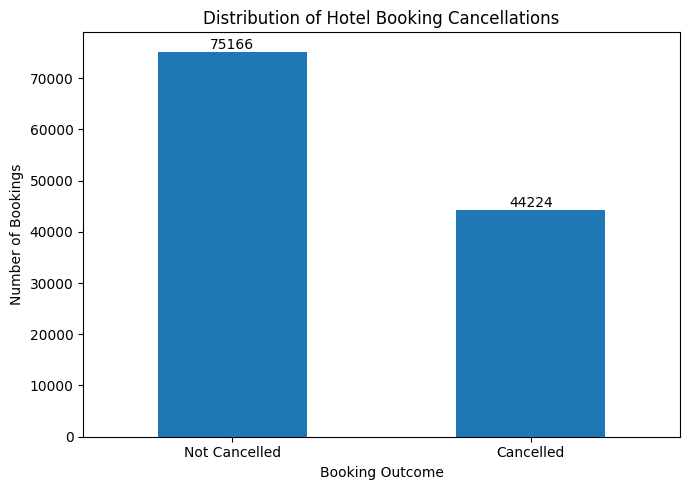

In [139]:
target_counts_named = df["is_canceled"].map({
    0: "Not Cancelled",
    1: "Cancelled"
}).value_counts()

ax = target_counts_named.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Hotel Booking Cancellations")
plt.xlabel("Booking Outcome")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

total = len(df)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Target Distribution Observation

The dataset contains 75,166 non-cancelled bookings (approximately 62.96%) and 44,224 cancelled bookings (approximately 37.04%).

Therefore, the target variable is moderately imbalanced, with non-cancelled bookings forming the majority class. The imbalance is not extremely severe, but model evaluation should not rely only on accuracy. Metrics such as precision, recall, F1-score, ROC-AUC, and the confusion matrix will also be considered during model development.

## 3. Missing Value Analysis

Missing values are investigated to understand which variables contain incomplete information and how significant the missingness is.

No missing-value treatment is performed in this notebook. Appropriate handling strategies will be determined during the preprocessing stage.

Missing-value summary

In [140]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


Missing-value visualization

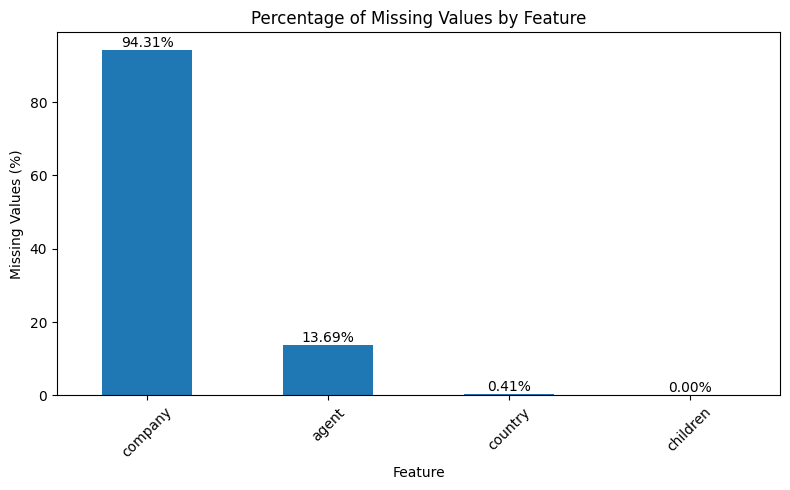

In [141]:
ax = missing_summary["Missing Percentage"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### Missing Value Observations

Missing values occur in four attributes:

- `company` has the largest proportion of missing values, at approximately 94.31%.
- `agent` contains approximately 13.69% missing values.
- `country` contains only a small proportion of missing values, approximately 0.41%.
- `children` contains only four missing records.

The meaning of these missing values must be investigated before selecting a treatment strategy. For example, a missing `company` or `agent` value may potentially represent a booking that was not associated with a company or travel agent rather than an accidental loss of information.

Therefore, rows or columns will not be removed solely because they contain missing values at this stage.

## 4. Duplicate Record Investigation

Exact duplicate rows are investigated as a potential data-quality issue.

However, the dataset does not contain a unique booking identifier. Therefore, identical rows cannot automatically be assumed to represent erroneous duplicate bookings.

Count duplicates

In [142]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Number of exact duplicate rows:", duplicate_count)
print(f"Percentage of exact duplicate rows: {duplicate_percentage:.2f}%")

Number of exact duplicate rows: 31994
Percentage of exact duplicate rows: 26.80%


Inspect some duplicates

In [143]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
132,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
198,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


### Duplicate Record Observation

The dataset contains 31,994 rows that are exact duplicates across all available attributes.

However, there is no unique reservation or booking identifier in the dataset. It is therefore possible that some identical rows represent separate bookings with the same recorded characteristics rather than accidental duplicate records.

The duplicate records will be investigated further during preprocessing before a final decision is made regarding removal.

## 5. Investigation of Unusual Observations

Several numerical variables are examined to identify observations that differ substantially from typical bookings.

These observations are not assumed to be errors. They may represent legitimate special cases such as group bookings, complimentary stays, day-use reservations, or other hotel-specific situations.

The purpose of this analysis is to identify records requiring further investigation before any preprocessing decision is made.

In [144]:
zero_guest_bookings = (
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
).sum()

zero_night_bookings = (
    (df["stays_in_weekend_nights"] == 0) &
    (df["stays_in_week_nights"] == 0)
).sum()

negative_adr = (df["adr"] < 0).sum()
zero_adr = (df["adr"] == 0).sum()
very_high_adr = (df["adr"] > 1000).sum()
large_adult_bookings = (df["adults"] > 10).sum()

unusual_summary = pd.DataFrame({
    "Observation": [
        "Bookings with zero recorded guests",
        "Bookings with zero recorded nights",
        "Bookings with negative ADR",
        "Bookings with ADR = 0",
        "Very high ADR values (>1000) for inspection",
        "Large-group bookings (>10 adults)"
    ],
    "Count": [
        zero_guest_bookings,
        zero_night_bookings,
        negative_adr,
        zero_adr,
        very_high_adr,
        large_adult_bookings
    ]
})

unusual_summary

,Observation,Count
0,Bookings with zero recorded guests,180
1,Bookings with zero recorded nights,715
2,Bookings with negative ADR,1
3,Bookings with ADR = 0,1959
4,Very high ADR values (>1000) for inspection,1
5,Large-group bookings (>10 adults),12


Inspect numerical extremes

In [145]:
selected_numeric_features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "days_in_waiting_list",
    "adr"
]

df[selected_numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0


Inspect the negative ADR row

In [146]:
df[df["adr"] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


Inspect extremely high ADR

In [147]:
df[df["adr"] > 1000]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,12.0,NaN,0,Transient,5400.0,0,0,Canceled,2016-02-19


Inspect zero-guest records

In [148]:
df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
].head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,NaN,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,NaN,174.0,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,0.0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05
4127,Resort Hotel,1,0,2016,February,8,15,0,0,0,0.0,0,SC,NaN,Offline TA/TO,TA/TO,0,0,0,P,P,0,No Deposit,NaN,383.0,0,Transient,0.0,0,0,Canceled,2016-02-15
9376,Resort Hotel,1,0,2016,November,48,21,0,0,0,0.0,0,SC,NaN,Offline TA/TO,TA/TO,0,0,0,P,P,0,No Deposit,NaN,386.0,0,Group,0.0,0,0,Canceled,2016-11-21
31765,Resort Hotel,0,31,2016,December,53,27,2,8,0,0.0,0,BB,PRT,Direct,Direct,0,0,0,D,D,3,No Deposit,NaN,NaN,0,Transient,28.0,1,0,Check-Out,2017-01-06
32029,Resort Hotel,0,4,2017,January,2,14,0,1,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,G,0,No Deposit,168.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2017-01-15
32827,Resort Hotel,0,46,2017,January,4,25,3,9,0,0.0,0,SC,FRA,Direct,Direct,0,0,0,A,I,8,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2017-02-06


### Unusual Value Observations

Several potentially unusual records were identified:

- 180 bookings contain no recorded adults, children, or babies.
- 715 bookings record zero weekend and zero weekday nights.
- One record contains a negative average daily rate (`adr`).
- 1,959 bookings have an `adr` equal to zero.
- One booking has an `adr` above 1,000.
- A small number of bookings contain unusually large numbers of adults.

These observations are not automatically classified as errors. Some may represent legitimate special booking situations, complimentary stays, group reservations, cancelled bookings, or other operational cases.

**ADR (Average Daily Rate)** represents the average daily room rate associated with a booking. Extreme or unusual ADR values are investigated as potential special cases or data-quality issues, but they are not automatically treated as errors.

Appropriate treatment will therefore be determined during preprocessing after further investigation.

## 6. Numerical Feature Analysis

The distributions of important numerical features are examined to identify skewness, unusual observations, and possible relationships that may influence preprocessing and modelling decisions.

Histograms of selected numerical variables

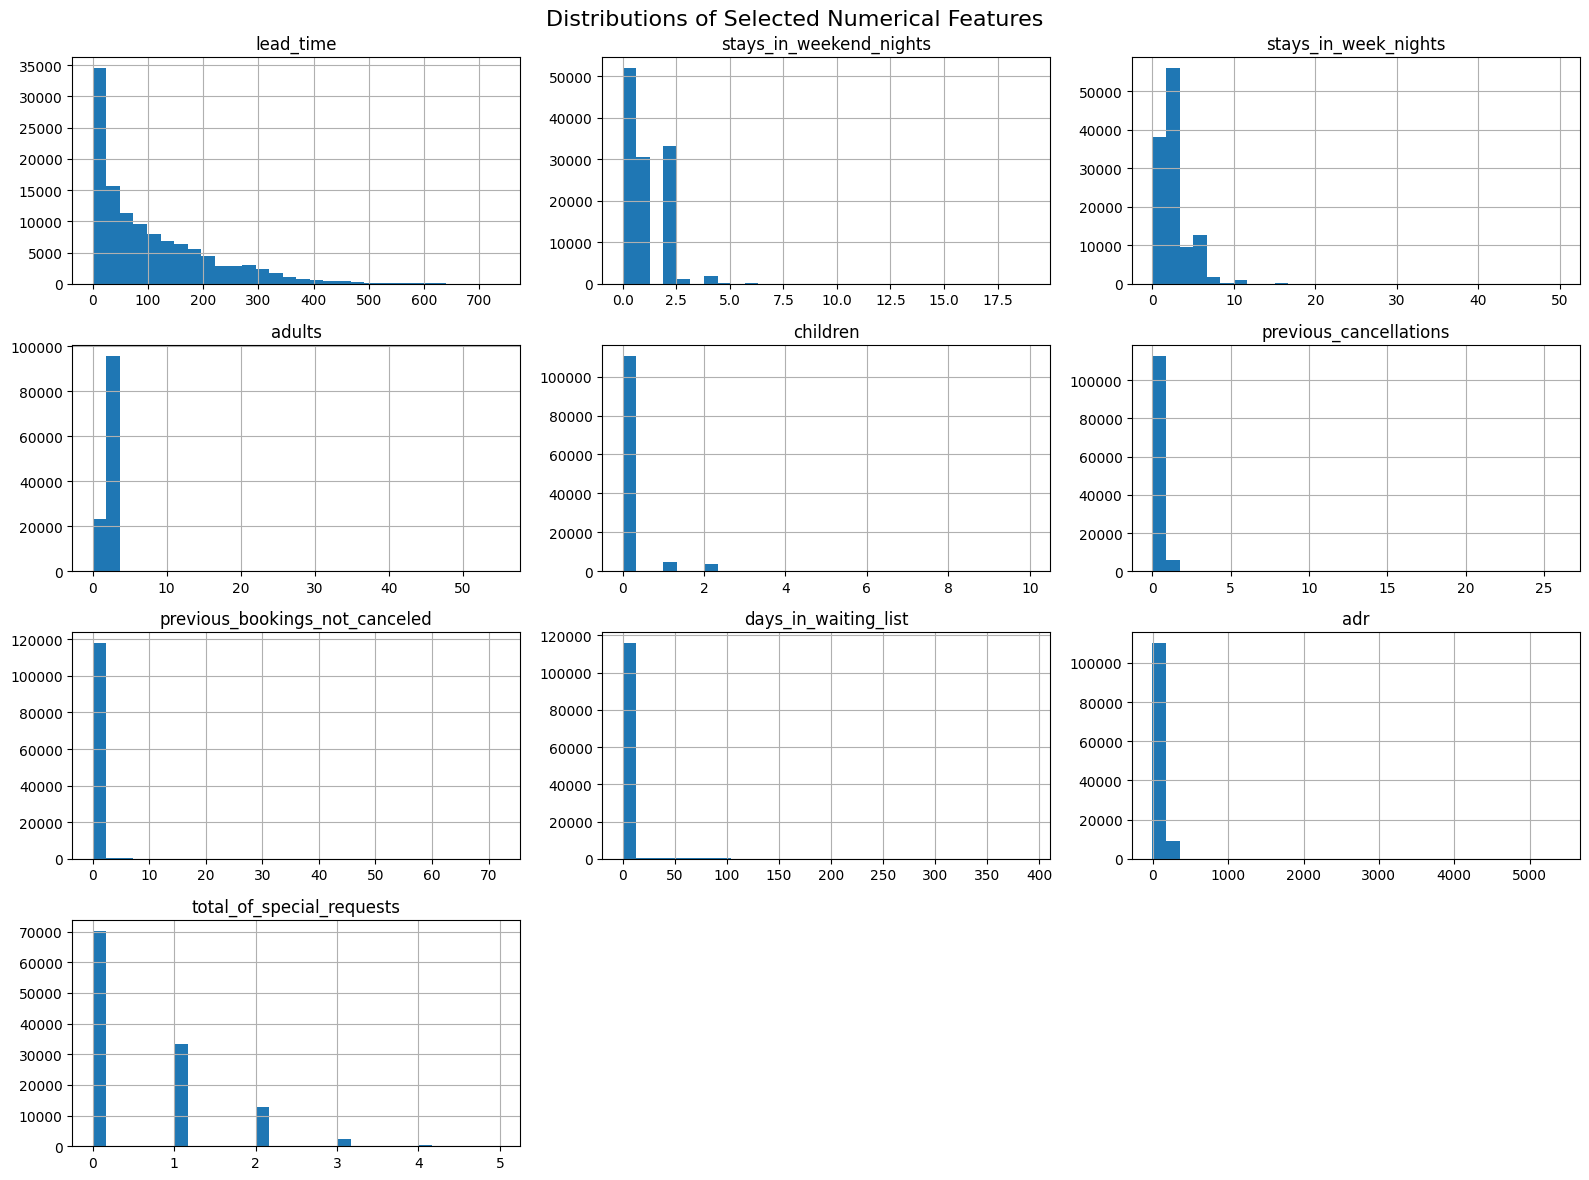

In [149]:
features_to_plot = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "days_in_waiting_list",
    "adr",
    "total_of_special_requests"
]

df[features_to_plot].hist(
    bins=30,
    figsize=(16, 12)
)

plt.suptitle(
    "Distributions of Selected Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

Boxplots for key continuous features

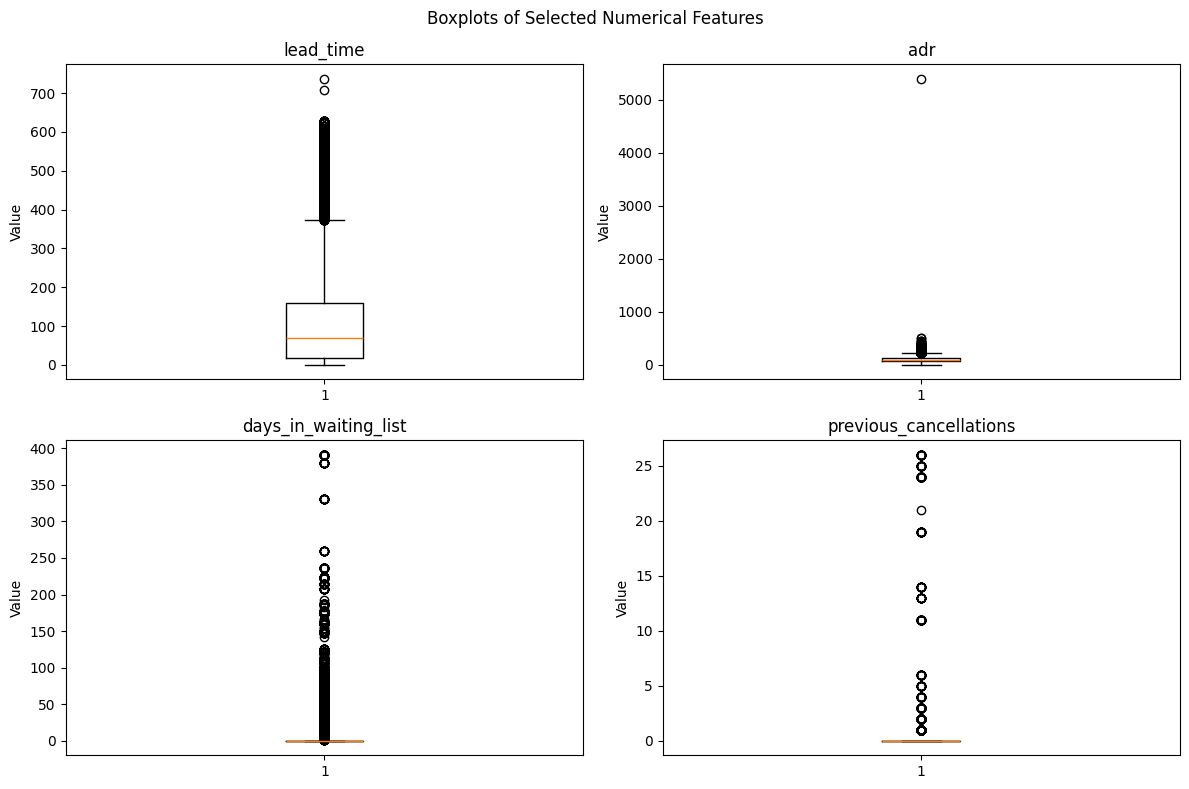

In [150]:
boxplot_features = [
    "lead_time",
    "adr",
    "days_in_waiting_list",
    "previous_cancellations"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

for ax, feature in zip(axes.flatten(), boxplot_features):
    ax.boxplot(df[feature].dropna())
    ax.set_title(feature)
    ax.set_ylabel("Value")

plt.suptitle("Boxplots of Selected Numerical Features")
plt.tight_layout()
plt.show()

## 7. Categorical Feature Analysis

Categorical variables are examined to understand their possible values, frequency distributions, and whether some variables contain very high numbers of categories.

### Categorical and Identifier-Like Feature Cardinality

Although some categorical or identifier-like variables are stored as text and others are numerically encoded, the following features are examined according to their meaning rather than only their Pandas data type.

The number of unique values is important because high-cardinality variables may require special treatment or may not be suitable for direct one-hot encoding.

In [151]:
categorical_features = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type",
    "agent",
    "company"
]

categorical_summary = pd.DataFrame({
    "Feature": categorical_features,
    "Unique Values": [
        df[col].nunique(dropna=False)
        for col in categorical_features
    ]
})

categorical_summary.sort_values(
    by="Unique Values",
    ascending=False
)

,Feature,Unique Values
12,company,353
11,agent,334
3,country,178
1,arrival_date_month,12
8,assigned_room_type,12
7,reserved_room_type,10
4,market_segment,8
5,distribution_channel,5
2,meal,5
10,customer_type,4


Display categorical distributions

In [152]:
categorical_features_to_check = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "is_repeated_guest"
]

for feature in categorical_features_to_check:
    print(f"\n--- {feature} ---")
    print(df[feature].value_counts(dropna=False))


--- hotel ---
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

--- meal ---
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

--- market_segment ---
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

--- distribution_channel ---
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

--- deposit_type ---
deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

--- customer_type ---
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

--- is_repeated_guest ---
is_repeated_guest
0    115580
1   

Hotel type distribution

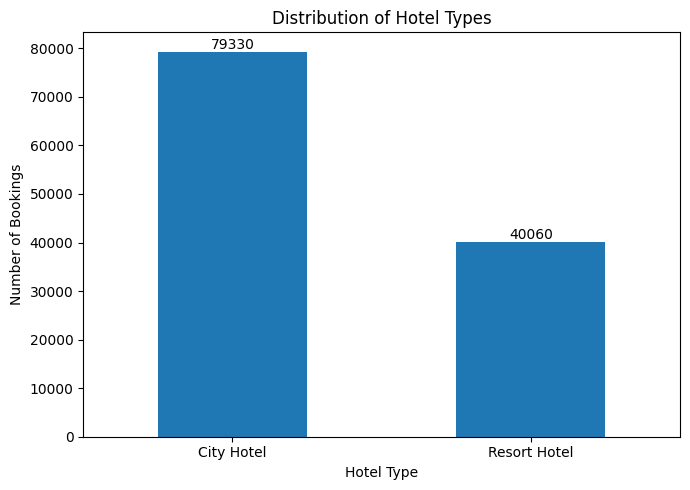

In [153]:
hotel_counts = df["hotel"].value_counts()

ax = hotel_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Hotel Types")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## 8. Temporal Coverage Analysis

The dataset contains hotel bookings across multiple years. Understanding the chronological coverage is important because the eventual train/test split strategy may need to account for time.

A temporary arrival-date variable is constructed for analysis only. The original dataset is not modified.

In [154]:
arrival_date_temp = pd.to_datetime(
    df["arrival_date_year"].astype(str)
    + "-"
    + df["arrival_date_month"]
    + "-"
    + df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d"
)

print("Earliest arrival date:", arrival_date_temp.min())
print("Latest arrival date:", arrival_date_temp.max())

Earliest arrival date: 2015-07-01 00:00:00
Latest arrival date: 2017-08-31 00:00:00


In [155]:
bookings_by_year = df["arrival_date_year"].value_counts().sort_index()

bookings_by_year

,count
arrival_date_year,
2015,21996
2016,56707
2017,40687


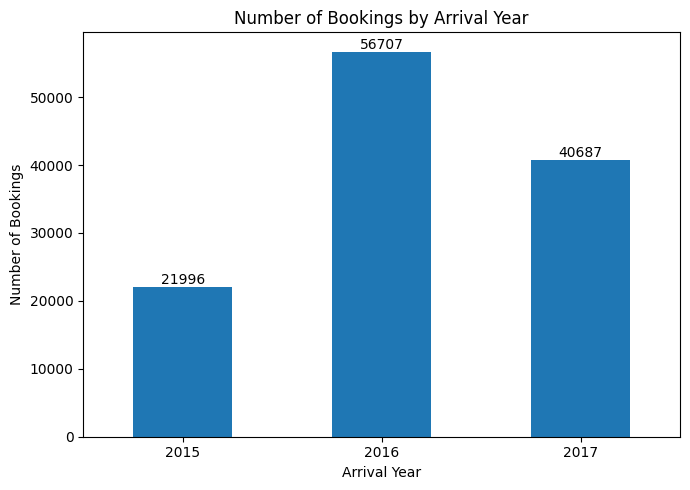

In [156]:
ax = bookings_by_year.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Number of Bookings by Arrival Year")
plt.xlabel("Arrival Year")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Temporal Coverage Observation

The dataset contains bookings across 2015, 2016, and 2017.

Because the intended system predicts cancellation for future reservations, the chronological structure of the data will be considered when selecting the train/test split strategy. A time-aware split will be evaluated during preprocessing and compared with an appropriate stratified random split before the final validation strategy is selected.

## 9. Relationship Between Features and Cancellation

The following analysis investigates how selected booking characteristics relate to the target variable `is_canceled`.

The observed relationships are descriptive associations and should not automatically be interpreted as causal relationships.

Cancellation rate by hotel

In [157]:
hotel_cancellation = (
    df.groupby("hotel")["is_canceled"]
    .agg(["count", "mean"])
)

hotel_cancellation["Cancellation Rate (%)"] = (
    hotel_cancellation["mean"] * 100
).round(2)

hotel_cancellation

,count,mean,Cancellation Rate (%)
hotel,,,
City Hotel,79330,0.417270,41.73
Resort Hotel,40060,0.277634,27.76


Plot cancellation rate by hotel

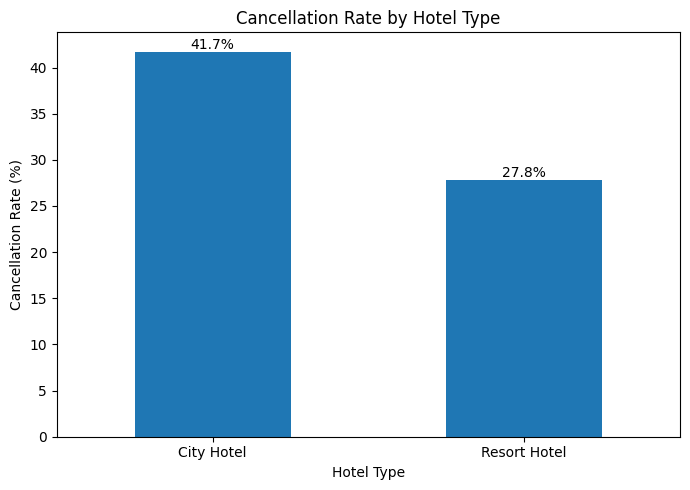

In [158]:
hotel_cancel_rate = (
    df.groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
)

ax = hotel_cancel_rate.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

Cancellation rate by deposit type

In [159]:
deposit_cancel_rate = (
    df.groupby("deposit_type")["is_canceled"]
    .agg(["count", "mean"])
)

deposit_cancel_rate["Cancellation Rate (%)"] = (
    deposit_cancel_rate["mean"] * 100
).round(2)

deposit_cancel_rate.sort_values(
    "Cancellation Rate (%)",
    ascending=False
)

,count,mean,Cancellation Rate (%)
deposit_type,,,
Non Refund,14587,0.993624,99.36
No Deposit,104641,0.283770,28.38
Refundable,162,0.222222,22.22


Cancellation rate by customer type

In [160]:
customer_cancel_rate = (
    df.groupby("customer_type")["is_canceled"]
    .agg(["count", "mean"])
)

customer_cancel_rate["Cancellation Rate (%)"] = (
    customer_cancel_rate["mean"] * 100
).round(2)

customer_cancel_rate.sort_values(
    "Cancellation Rate (%)",
    ascending=False
)

,count,mean,Cancellation Rate (%)
customer_type,,,
Transient,89613,0.407463,40.75
Contract,4076,0.309617,30.96
Transient-Party,25124,0.254299,25.43
Group,577,0.102253,10.23


Cancellation by market segment

In [161]:
market_cancel_rate = (
    df.groupby("market_segment")["is_canceled"]
    .agg(["count", "mean"])
)

market_cancel_rate["Cancellation Rate (%)"] = (
    market_cancel_rate["mean"] * 100
).round(2)

market_cancel_rate.sort_values(
    "Cancellation Rate (%)",
    ascending=False
)

,count,mean,Cancellation Rate (%)
market_segment,,,
Undefined,2,1.000000,100.00
Groups,19811,0.610620,61.06
Online TA,56477,0.367211,36.72
Offline TA/TO,24219,0.343160,34.32
Aviation,237,0.219409,21.94
Corporate,5295,0.187347,18.73
Direct,12606,0.153419,15.34
Complementary,743,0.130552,13.06


Lead time vs cancellation

In [162]:
df.groupby("is_canceled")["lead_time"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,79.984687,91.109888,0.0,9.0,45.0,124.0,737.0
1,44224.0,144.848815,118.624829,0.0,48.0,113.0,214.0,629.0


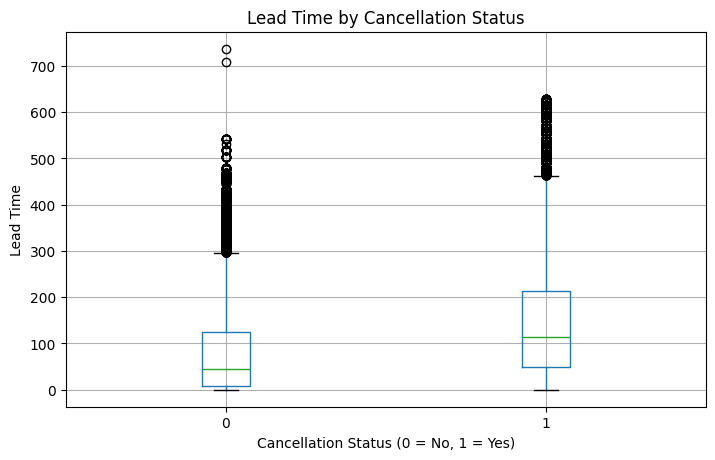

In [163]:
df.boxplot(
    column="lead_time",
    by="is_canceled",
    figsize=(8, 5)
)

plt.title("Lead Time by Cancellation Status")
plt.suptitle("")
plt.xlabel("Cancellation Status (0 = No, 1 = Yes)")
plt.ylabel("Lead Time")
plt.show()

Previous cancellation history

In [164]:
previous_cancel_analysis = (
    df.groupby("is_canceled")["previous_cancellations"]
    .mean()
)

previous_cancel_analysis

,previous_cancellations
is_canceled,
0,0.015792
1,0.208348


Special requests and cancellation

In [165]:
special_request_cancel_rate = (
    df.groupby("total_of_special_requests")["is_canceled"]
    .agg(["count", "mean"])
)

special_request_cancel_rate["Cancellation Rate (%)"] = (
    special_request_cancel_rate["mean"] * 100
).round(2)

special_request_cancel_rate

,count,mean,Cancellation Rate (%)
total_of_special_requests,,,
0,70318,0.477204,47.72
1,33226,0.220249,22.02
2,12969,0.220989,22.10
3,2497,0.178614,17.86
4,340,0.105882,10.59
5,40,0.050000,5.00


Numeric correlation with target

In [166]:
correlation_features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

numeric_corr = (
    df[correlation_features + ["is_canceled"]]
    .corr()["is_canceled"]
    .drop("is_canceled")
    .sort_values(key=abs, ascending=False)
)

numeric_corr

,is_canceled
lead_time,0.293123
total_of_special_requests,-0.234658
required_car_parking_spaces,-0.195498
booking_changes,-0.144381
previous_cancellations,0.110133
is_repeated_guest,-0.084793
adults,0.060017
previous_bookings_not_canceled,-0.057358
days_in_waiting_list,0.054186
adr,0.047557


Correlation visualization

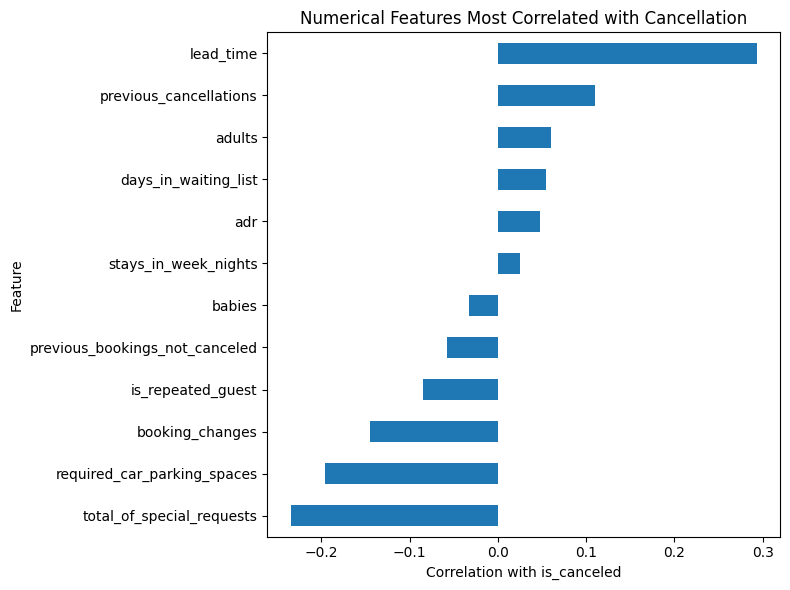

In [167]:
ax = numeric_corr.head(12).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Numerical Features Most Correlated with Cancellation")
plt.xlabel("Correlation with is_canceled")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Feature–Target Relationship Observations

Several descriptive relationships were observed:

- City Hotel bookings have a higher observed cancellation rate (approximately 41.73%) than Resort Hotel bookings (approximately 27.76%).
- `deposit_type` shows substantial differences in cancellation rates. In particular, the `Non Refund` category has a very high observed cancellation rate. This relationship requires further investigation rather than being interpreted causally.
- Transient customers show a higher observed cancellation rate than the other customer-type categories.
- Cancelled bookings have a considerably higher average lead time (approximately 144.85 days) than non-cancelled bookings (approximately 79.98 days).
- Customers associated with cancelled bookings have a higher mean number of previous cancellations.
- The observed cancellation rate generally decreases as the number of special requests increases.
- Among the examined numerical features, `lead_time`, `total_of_special_requests`, and `required_car_parking_spaces` show some of the stronger linear associations with the target.

These results describe associations within this dataset and do not establish causal relationships. Category sizes must also be considered when interpreting percentages; for example, very small categories can produce extreme cancellation rates that may not generalize.

## 10. Data Leakage Investigation

Data leakage occurs when a model is given information that would not legitimately be available at the time the prediction is made, especially information that directly or indirectly reveals the target outcome.

Because this project aims to predict cancellation before the final reservation outcome is known, outcome-related variables must be carefully investigated.

Check reservation_status against target

In [168]:
pd.crosstab(
    df["reservation_status"],
    df["is_canceled"]
)

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


Normalized crosstab

In [169]:
pd.crosstab(
    df["reservation_status"],
    df["is_canceled"],
    normalize="index"
).round(3)

is_canceled,0,1
reservation_status,,
Canceled,0.0,1.0
Check-Out,1.0,0.0
No-Show,0.0,1.0


Inspect reservation status date

In [170]:
df[
    [
        "is_canceled",
        "reservation_status",
        "reservation_status_date"
    ]
].head(10)

,is_canceled,reservation_status,reservation_status_date
0,0,Check-Out,2015-07-01
1,0,Check-Out,2015-07-01
2,0,Check-Out,2015-07-02
3,0,Check-Out,2015-07-02
4,0,Check-Out,2015-07-03
5,0,Check-Out,2015-07-03
6,0,Check-Out,2015-07-03
7,0,Check-Out,2015-07-03
8,1,Canceled,2015-05-06
9,1,Canceled,2015-04-22


### Data Leakage Observation

`reservation_status` directly represents the final reservation outcome. For example, records with the status `Canceled` correspond to cancelled bookings, while `Check-Out` represents completed stays.

Therefore, using `reservation_status` as a predictive input would reveal information about the target variable and cause severe data leakage.

`reservation_status_date` is also outcome-related because it represents the date on which the final reservation status was established. This information would not legitimately be available when predicting cancellation in advance.

Therefore, the following variables are identified for exclusion from the predictive feature set during preprocessing:

- `reservation_status`
- `reservation_status_date`

Other timing-sensitive features such as `assigned_room_type`, `booking_changes`, and `days_in_waiting_list` will also be investigated during preprocessing according to the final prediction point.

## 11. Preliminary EDA Conclusions

The exploratory analysis identified several characteristics that will influence preprocessing and model development:

1. The dataset contains 119,390 records and 32 variables.
2. The prediction target is `is_canceled`, making the problem a binary classification task.
3. Approximately 62.96% of bookings were not cancelled, while approximately 37.04% were cancelled, indicating moderate class imbalance.
4. Missing values occur mainly in `company`, `agent`, `country`, and `children`.
5. A substantial number of exact duplicate rows exist, but their validity must be investigated because the dataset has no unique booking identifier.
6. Several unusual observations exist, including zero-guest bookings, zero-night bookings, a negative ADR value, and extreme ADR and guest-count values.
7. Numerical variables such as lead time and ADR contain skewed distributions and potential outliers.
8. Several categorical variables contain multiple categories and will require appropriate encoding during preprocessing.
9. Booking characteristics including hotel type, deposit type, market segment, previous cancellation behaviour, lead time, and special requests show relationships with the cancellation outcome and should be investigated further.
10. `reservation_status` and `reservation_status_date` represent clear data-leakage risks and should not be included as predictive inputs.
11. Other timing-sensitive variables will be evaluated according to whether they would legitimately be available at the chosen prediction point.
12. No preprocessing decisions are finalized in this notebook. Data-cleaning, feature-engineering, encoding, scaling, feature-selection, and train/test split decisions will be performed and justified in Notebook 02.

In [171]:
print("Dataset shape after EDA:", df.shape)

Dataset shape after EDA: (119390, 32)


### EDA Data Integrity Check

The dataset remains at 119,390 rows and 32 columns after EDA because this notebook performs investigation only. No rows, columns, missing values, duplicates, or outliers have been modified or removed.

All preprocessing decisions will be implemented separately in Notebook 02.